# Act 1 — Bề mặt vs. Thực tế

> **Câu hỏi:** Doanh thu tăng — nhưng bao nhiêu còn lại sau discount, returns và cost of goods?

**Dữ liệu:** orders.csv · order_items.csv · products.csv · returns.csv · reviews.csv
**Luận điểm:** Discount và returns là cơ chế chính kéo gross margin từ 20,8% xuống 8,5% trong 10 năm.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from scipy.stats import mannwhitneyu

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "#fafafa",
    "axes.facecolor":    "#fafafa",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

PALETTE = {
    "positive": "#2d6a4f",
    "negative": "#c1121f",
    "promo":    "#e76f51",
    "organic":  "#457b9d",
    "neutral":  "#adb5bd",
    "warning":  "#e9c46a",
    "gp":       "#2d6a4f",
    "cogs":     "#adb5bd",
    "discount": "#c1121f",
    "returns":  "#e9c46a",
}

def save_chart(fig, path, dpi=150):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    sz = Path(path).stat().st_size // 1024
    print(f"Saved: {path}  ({sz} KB)")
    if sz < 100:
        print(f"  CANH BAO: PNG nho hon 100KB ({sz} KB)")

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
print("Config loaded.")

Config loaded.


In [2]:
oat = pd.read_parquet("oat.parquet")
oat["order_date"] = pd.to_datetime(oat["order_date"])
print(f"OAT loaded: {len(oat):,} rows")

# Validate OAT vs sales.csv
sales = pd.read_csv("data/sales.csv", parse_dates=["Date"])
sales.columns = [c.strip() for c in sales.columns]
sales_total = sales["Revenue"].sum()
oat_gross   = oat["gross_revenue_line"].sum()
print(f"sales.csv total revenue  : {sales_total:,.0f} VND")
print(f"OAT gross_revenue_line   : {oat_gross:,.0f} VND")
print(f"Chenh lech               : {abs(oat_gross - sales_total)/sales_total:.2%}")

# Enrich OAT with avg review rating per order
reviews = pd.read_csv("data/reviews.csv", parse_dates=["review_date"])
avg_rating_per_order = reviews.groupby("order_id")["rating"].mean().rename("avg_rating")
oat = oat.merge(avg_rating_per_order, on="order_id", how="left")
print(f"avg_rating null rate: {oat['avg_rating'].isna().mean():.1%}")
display(oat[["order_date","gross_revenue_line","discount_amount","refund_amount",
             "gross_profit","has_promo","avg_rating"]].head())

OAT loaded: 714,669 rows
sales.csv total revenue  : 16,430,476,586 VND
OAT gross_revenue_line   : 16,430,476,586 VND
Chenh lech               : 0.00%


avg_rating null rate: 81.7%


,order_date,gross_revenue_line,discount_amount,refund_amount,gross_profit,has_promo,avg_rating
0,2012-07-04,7967.54,0.0,0.00,590.953941,False,5.0
1,2012-07-04,71163.75,0.0,52458.01,8249.820384,False,NaN
2,2012-07-04,33660.99,0.0,0.00,3387.953233,False,5.0
3,2012-07-04,53196.25,0.0,0.00,7169.097610,False,NaN
4,2012-07-06,1597.84,0.0,0.00,549.143643,False,NaN


In [3]:
# Tong hop theo thang
try:
    monthly = oat.groupby(pd.Grouper(key="order_date", freq="ME")).agg(
        gross_revenue   =("gross_revenue_line", "sum"),
        discount_leakage=("discount_amount",    "sum"),
        return_leakage  =("refund_amount",       "sum"),
        cogs_total      =("cogs_quantity",       "sum"),
        gross_profit    =("gross_profit",        "sum"),
    )
except Exception:
    monthly = oat.groupby(pd.Grouper(key="order_date", freq="M")).agg(
        gross_revenue   =("gross_revenue_line", "sum"),
        discount_leakage=("discount_amount",    "sum"),
        return_leakage  =("refund_amount",       "sum"),
        cogs_total      =("cogs_quantity",       "sum"),
        gross_profit    =("gross_profit",        "sum"),
    )

monthly["net_revenue_chart"] = (
    monthly["gross_revenue"] - monthly["discount_leakage"] - monthly["return_leakage"]
)
monthly["gp_real"] = (monthly["net_revenue_chart"] - monthly["cogs_total"]).clip(lower=0)

total_discount = monthly["discount_leakage"].sum()
total_return   = monthly["return_leakage"].sum()

oat["year"] = oat["order_date"].dt.year
yr_first = oat[oat["year"] == oat["year"].min()]
yr_last  = oat[oat["year"] == oat["year"].max()]
margin_first = yr_first["gross_profit"].sum() / yr_first["net_revenue"].sum() * 100
margin_last  = yr_last["gross_profit"].sum()  / yr_last["net_revenue"].sum()  * 100

avg_rating_promo   = oat[oat["has_promo"]]["avg_rating"].mean()
avg_rating_organic = oat[~oat["has_promo"]]["avg_rating"].mean()

print(f"Total discount leakage 10yr : {total_discount:,.0f} VND")
print(f"Total return leakage 10yr   : {total_return:,.0f} VND")
print(f"Gross margin year 1         : {margin_first:.1f}%  ->  year last: {margin_last:.1f}%")
print(f"Avg rating promo: {avg_rating_promo:.2f}  |  organic: {avg_rating_organic:.2f}")

Total discount leakage 10yr : 749,607,320 VND
Total return leakage 10yr   : 510,660,320 VND
Gross margin year 1         : 20.8%  ->  year last: 8.5%
Avg rating promo: 3.93  |  organic: 3.94


Saved: outputs/charts/chart1_revenue_anatomy.png  (366 KB)


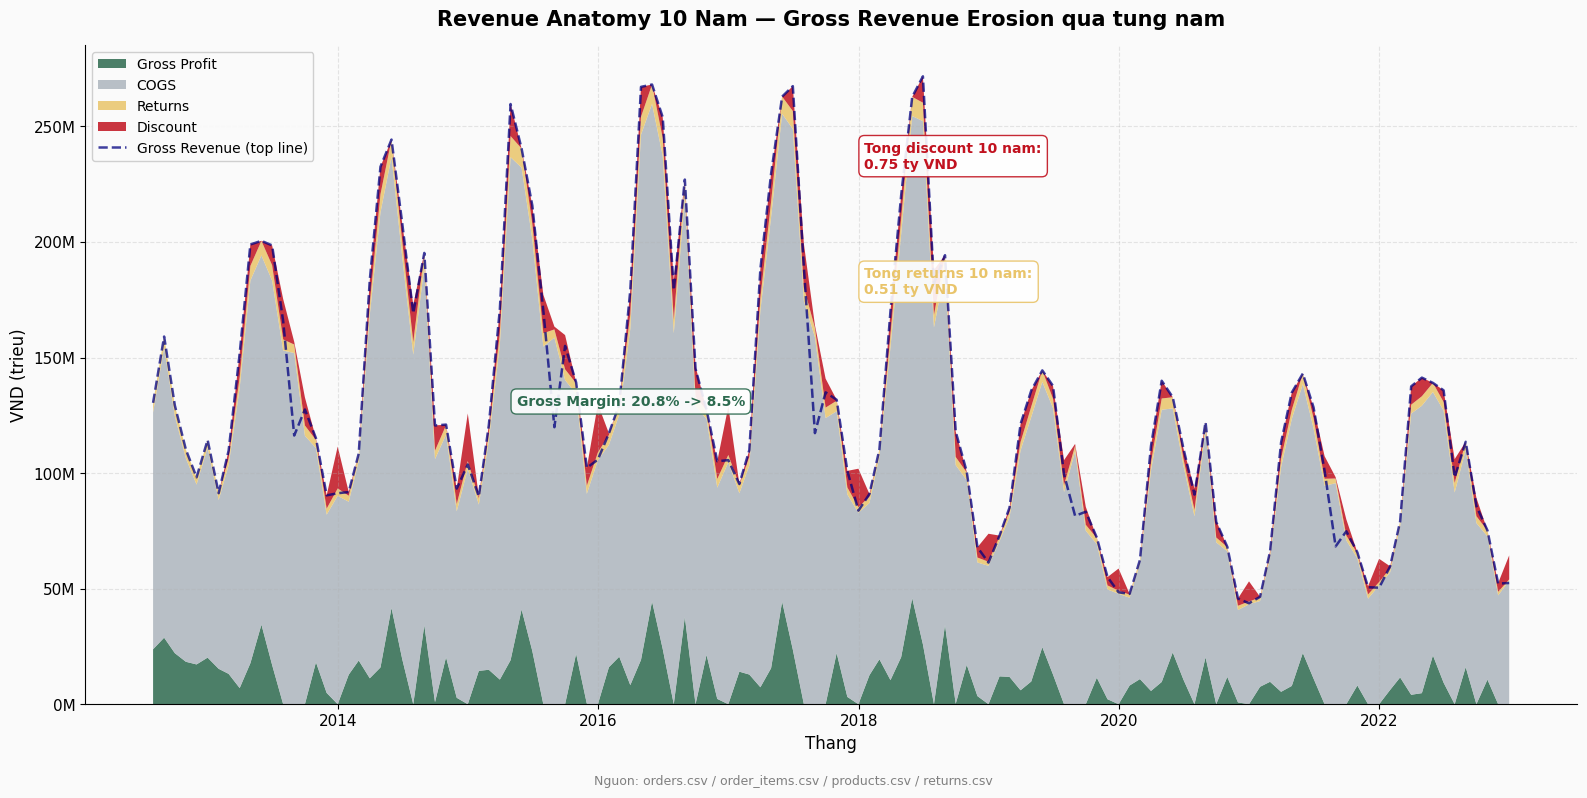

In [4]:
# Chart 1 — Revenue Anatomy (Stacked Area)
x = monthly.index

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_facecolor("#fafafa")

ax.stackplot(
    x,
    monthly["gp_real"],
    monthly["cogs_total"],
    monthly["return_leakage"],
    monthly["discount_leakage"],
    labels=["Gross Profit", "COGS", "Returns", "Discount"],
    colors=[PALETTE["gp"], PALETTE["cogs"], PALETTE["returns"], PALETTE["discount"]],
    alpha=0.85,
)
ax.plot(x, monthly["gross_revenue"], color="navy", linewidth=1.8,
        linestyle="--", label="Gross Revenue (top line)", alpha=0.75)

ymax = monthly["gross_revenue"].max()
ax.annotate(
    f"Tong discount 10 nam:\n{total_discount/1e9:.2f} ty VND",
    xy=(x[len(x)//2], ymax * 0.92),
    xytext=(20, -30), textcoords="offset points",
    fontsize=10, fontweight="bold", color=PALETTE["discount"],
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=PALETTE["discount"], alpha=0.9),
)
ax.annotate(
    f"Tong returns 10 nam:\n{total_return/1e9:.2f} ty VND",
    xy=(x[len(x)//2], ymax * 0.72),
    xytext=(20, -30), textcoords="offset points",
    fontsize=10, fontweight="bold", color=PALETTE["returns"],
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=PALETTE["returns"], alpha=0.9),
)
ax.annotate(
    f"Gross Margin: {margin_first:.1f}% -> {margin_last:.1f}%",
    xy=(x[len(x)//4], ymax * 0.52),
    xytext=(20, -20), textcoords="offset points",
    fontsize=10, fontweight="bold", color=PALETTE["gp"],
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=PALETTE["gp"], alpha=0.9),
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.set_title("Revenue Anatomy 10 Nam — Gross Revenue Erosion qua tung nam",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Thang", fontsize=12)
ax.set_ylabel("VND (trieu)", fontsize=12)
ax.legend(loc="upper left", fontsize=10, framealpha=0.92)
fig.text(0.5, 0.01, "Nguon: orders.csv / order_items.csv / products.csv / returns.csv",
         ha="center", fontsize=9, color="grey")
plt.tight_layout(rect=[0, 0.03, 1, 1])
save_chart(fig, "outputs/charts/chart1_revenue_anatomy.png")
plt.show()

Saved: outputs/charts/chart2_double_loss_quadrant.png  (120 KB)


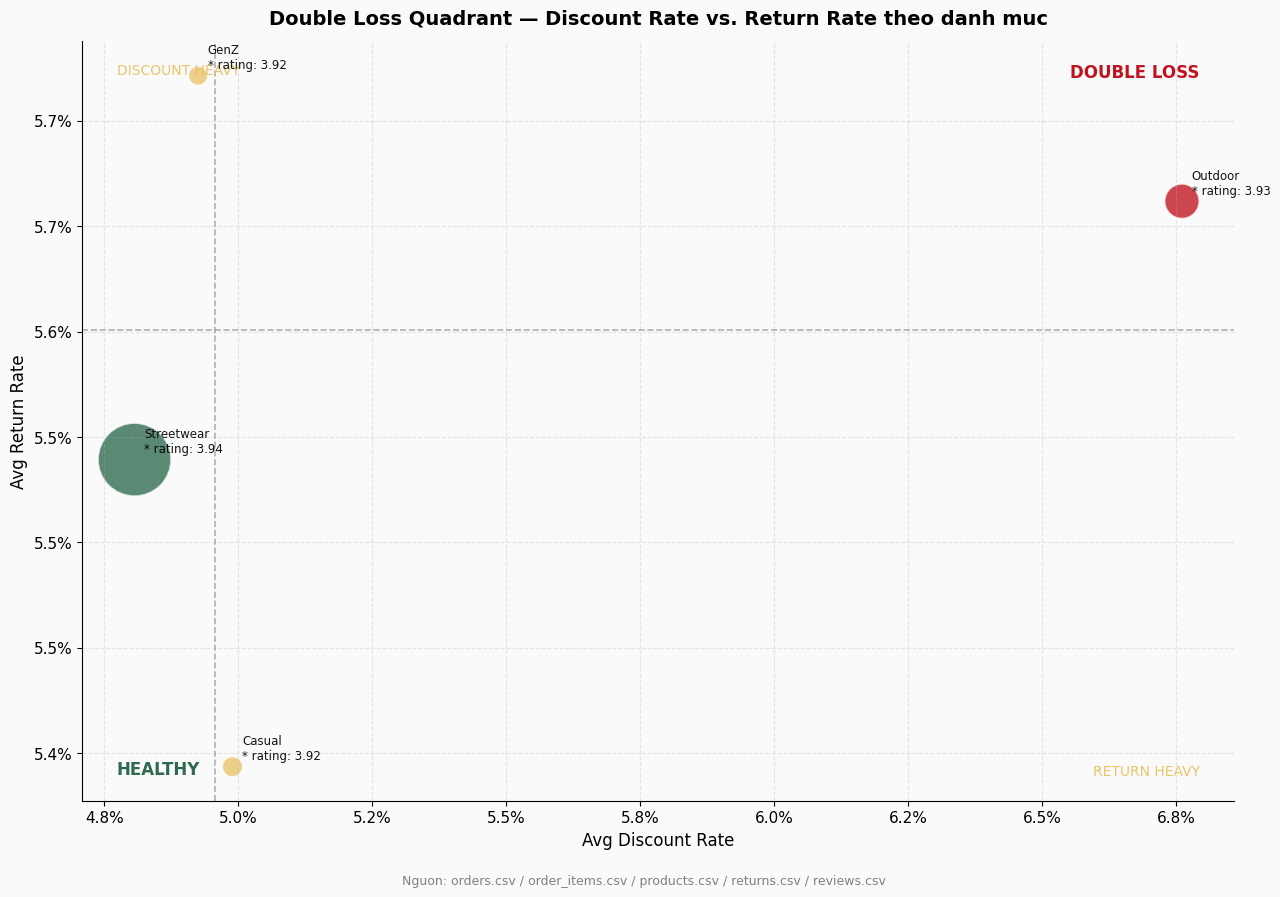

,category,avg_discount_rate,avg_return_rate,total_gross_revenue,avg_rating,bubble_size
1,GenZ,0.049249,0.057214,3.435991e+08,3.923856,200.000000
2,Outdoor,0.067613,0.056618,2.494883e+09,3.932943,637.398191
3,Streetwear,0.048063,0.055393,1.313135e+10,3.939829,2800.000000
0,Casual,0.049890,0.053937,4.606484e+08,3.924535,223.798418


In [5]:
# Chart 2 — Double Loss Quadrant (Bubble Scatter)
cat = oat.groupby("category").agg(
    avg_discount_rate   =("discount_rate",       "mean"),
    avg_return_rate     =("is_returned",          "mean"),
    total_gross_revenue =("gross_revenue_line",   "sum"),
    avg_rating          =("avg_rating",           "mean"),
).reset_index().dropna(subset=["category"])

med_x = cat["avg_discount_rate"].median()
med_y = cat["avg_return_rate"].median()

rev_min, rev_max = cat["total_gross_revenue"].min(), cat["total_gross_revenue"].max()
cat["bubble_size"] = (
    (cat["total_gross_revenue"] - rev_min) / (rev_max - rev_min + 1e-9) * (2800 - 200) + 200
)

def quadrant_color(r):
    if r["avg_discount_rate"] >= med_x and r["avg_return_rate"] >= med_y:
        return PALETTE["negative"]
    if r["avg_discount_rate"] < med_x and r["avg_return_rate"] < med_y:
        return PALETTE["positive"]
    return PALETTE["warning"]

colors_cat = [quadrant_color(r) for _, r in cat.iterrows()]

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_facecolor("#fafafa")
ax.scatter(
    cat["avg_discount_rate"], cat["avg_return_rate"],
    s=cat["bubble_size"], c=colors_cat, alpha=0.78,
    edgecolors="white", linewidth=1.5,
)
ax.axvline(med_x, color="grey", linewidth=1.2, linestyle="--", alpha=0.6)
ax.axhline(med_y, color="grey", linewidth=1.2, linestyle="--", alpha=0.6)

xlim, ylim = ax.get_xlim(), ax.get_ylim()
px, py = (xlim[1]-xlim[0])*0.03, (ylim[1]-ylim[0])*0.03
ax.text(xlim[1]-px, ylim[1]-py, "DOUBLE LOSS",     ha="right", va="top",    fontsize=12, fontweight="bold", color=PALETTE["negative"])
ax.text(xlim[0]+px, ylim[0]+py, "HEALTHY",         ha="left",  va="bottom", fontsize=12, fontweight="bold", color=PALETTE["positive"])
ax.text(xlim[0]+px, ylim[1]-py, "DISCOUNT HEAVY",  ha="left",  va="top",   fontsize=10, color=PALETTE["warning"])
ax.text(xlim[1]-px, ylim[0]+py, "RETURN HEAVY",    ha="right", va="bottom", fontsize=10, color=PALETTE["warning"])

for _, row in cat.iterrows():
    ax.annotate(
        f"{row['category']}\n* rating: {row['avg_rating']:.2f}",
        (row["avg_discount_rate"], row["avg_return_rate"]),
        textcoords="offset points", xytext=(7, 5), fontsize=8.5, alpha=0.92,
    )

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_title("Double Loss Quadrant — Discount Rate vs. Return Rate theo danh muc",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Avg Discount Rate", fontsize=12)
ax.set_ylabel("Avg Return Rate", fontsize=12)
fig.text(0.5, 0.01, "Nguon: orders.csv / order_items.csv / products.csv / returns.csv / reviews.csv",
         ha="center", fontsize=9, color="grey")
plt.tight_layout(rect=[0, 0.03, 1, 1])
save_chart(fig, "outputs/charts/chart2_double_loss_quadrant.png")
plt.show()

double_loss = cat[(cat["avg_discount_rate"] >= med_x) & (cat["avg_return_rate"] >= med_y)]["category"].tolist()
display(cat.sort_values("avg_return_rate", ascending=False))

In [6]:
total_gross = oat["gross_revenue_line"].sum()
erosion_pct = (total_discount + total_return) / total_gross * 100

print("=== FINDINGS ===")
print(f"Total discount leakage 10yr : {total_discount:>20,.0f} VND")
print(f"Total return leakage 10yr   : {total_return:>20,.0f} VND")
print(f"Gross margin year 1         : {margin_first:.1f}%")
print(f"Gross margin last year      : {margin_last:.1f}%")
print(f"Double Loss categories      : {double_loss}")
print(f"Leakage before GP           : {erosion_pct:.1f}%")
print(f"Avg rating promo vs organic : {avg_rating_promo:.2f} vs {avg_rating_organic:.2f}")

=== FINDINGS ===
Total discount leakage 10yr :          749,607,320 VND
Total return leakage 10yr   :          510,660,320 VND
Gross margin year 1         : 20.8%
Gross margin last year      : 8.5%
Double Loss categories      : ['Outdoor']
Leakage before GP           : 7.7%
Avg rating promo vs organic : 3.93 vs 3.94


## Findings

### Dữ liệu cho thấy gì
- Trong 10 năm, **749,607,320 VND** bị mất do discount và **510,660,320 VND** do returns — cộng lại xói mòn **7,7%** gross revenue trước khi đến gross profit.
- Gross margin giảm từ **20,8%** năm đầu xuống **8,5%** năm cuối — giảm 12,3 điểm phần trăm trong khi doanh thu vẫn tăng.
- Danh mục **Outdoor** nằm trong góc **Double Loss** — vừa discount rate cao vừa return rate cao.

### Ý nghĩa kinh doanh
Mỗi 100 VND gross revenue chỉ tạo ra khoảng 8,5 VND gross profit sau discount và COGS — giảm từ 20,8 VND một thập kỷ trước. Công ty đang tăng trưởng top-line trong khi khoét rỗng margin bên dưới.

### Bridge to Act 2
Nếu discount là cơ chế gây hao mòn, những promotion cụ thể nào chịu trách nhiệm — và chúng có đang tạo ra giá trị hay đang phá hủy?